# Combined judges sweep -- consultancy, asym / sym / last-d_B debate

Trains **13 judges** on one configurable dataset:

| # | judge | input channels | scoring |
|---|---|---|---|
| 1 | consultancy | $C$ | argmax confidence |
| 2 | asym 2-turn debate    | $2C$ | $\max_{a}\min_{b} P(c\mid\cdot)$ |
| 3 | asym 4-turn debate    | $2C$ | depth-4 minmax of $P$ |
| 4 | asym 2-turn control   | $4C$ | same as #2, channel slots randomized |
| 5 | asym 4-turn control   | $4C$ | same as #3, channel slots randomized |
| 6 | sym  2-turn debate    | $2C$ | $\max_{d_A}\min_{d_B}\max_a\min_b (p_{d_A}-p_{d_B})$ |
| 7 | sym  4-turn debate    | $2C$ | depth-6 symmetric minmax |
| 8 | sym  2-turn control   | $4C$ | same as #6, channel slots randomized |
| 9 | sym  4-turn control   | $4C$ | same as #7, channel slots randomized |
| 10 | last-$d_B$ 2-turn debate  | $2C$ | $\max_{d_A}\max_a\min_b (p_{d_A}-\max_d p_d)$ |
| 11 | last-$d_B$ 4-turn debate  | $2C$ | depth-4 cell minmax of the same leaf |
| 12 | last-$d_B$ 2-turn control | $4C$ | same as #10, channel slots randomized |
| 13 | last-$d_B$ 4-turn control | $4C$ | same as #11, channel slots randomized |

The consultancy judge is shared by all three scoring rules and is trained
**once**. Each judge saves its weights (`.pt`), per-step training loss
(`.npy`), and per-epoch accuracy (`.npy`). For debate / control judges we
also log A's selection accuracy.

File-name conventions:
* `consultancy_judge_<dataset>.pt`
* `debate_judge_2turn_<rule>_<dataset>.pt`, etc., with
  `<rule> in {asym, sym, lastdig}`.

Plots are saved as PNGs under `plot_dir`.


In [1]:
import os, gc, time, itertools
from pathlib import Path
from contextlib import nullcontext

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.optim.lr_scheduler import ExponentialLR
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

CONFIG = {
    # ----- dataset -----
    'dataset':            'mnist',   # one of:
                                     #   mnist, mnist_normalized,
                                     #   fashionmnist, fashionmnist_normalized,
                                     #   cifar10, cifar10_normalized
    # ----- image / mask geometry -----
    'img_size':           18,
    'grid_size':          6,
    'squares_to_keep':    4,
    # ----- training (shared) -----
    'batch_size':         128,
    'epochs':             10,
    'lr':                 1e-3,
    'lr_decay':           0.85,
    'forward_chunk':      16000,     # rows per judge forward pass
    'eval_amp':           True,
    # ----- consultancy specifics -----
    'consultancy_masks_per_image': 1296,    # = 6^4 to match the debate budgets
    # ----- 2-turn debate specifics (N_A * N_B = 1296 paths) -----
    'two_turn_N_A':       36,
    'two_turn_N_B':       36,
    # ----- 4-turn debate specifics (N_a1 * N_b1 * N_a2 * N_b2 = 1296 paths) -----
    'four_turn_N_a1':     6,
    'four_turn_N_b1':     6,
    'four_turn_N_a2':     6,
    'four_turn_N_b2':     6,
    # ----- evaluation -----
    'eval_batch':         32,        # smaller -- debate has more paths/image
    # ----- which scoring rules to run -----
    'scoring_rules':      ('asym', 'sym', 'lastdig'),
    # ----- IO -----
    'data_root':          './data',
    'plot_dir':           '/kaggle/working/combined_judges_plots',
    'data_dir':           '/kaggle/working/combined_judges_data',
    'weights_dir':        '/kaggle/working/combined_judges_weights',
    'device':             'cuda' if torch.cuda.is_available() else 'cpu',
}

for d in (CONFIG['plot_dir'], CONFIG['data_dir'], CONFIG['weights_dir']):
    os.makedirs(d, exist_ok=True)

print(f"device: {CONFIG['device']}")
if CONFIG['device'] == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)} | "
          f"free mem: {torch.cuda.mem_get_info()[0]/1e9:.2f} GB")
print(f"dataset: {CONFIG['dataset']}")
print(f"  consultancy: 1 x {CONFIG['consultancy_masks_per_image']} masks/img")
print(f"  2-turn:      N_A={CONFIG['two_turn_N_A']}, N_B={CONFIG['two_turn_N_B']} "
      f"-> {CONFIG['two_turn_N_A']*CONFIG['two_turn_N_B']} paths/img")
print(f"  4-turn:      ({CONFIG['four_turn_N_a1']}, {CONFIG['four_turn_N_b1']}, "
      f"{CONFIG['four_turn_N_a2']}, {CONFIG['four_turn_N_b2']}) "
      f"-> {CONFIG['four_turn_N_a1']*CONFIG['four_turn_N_b1']*CONFIG['four_turn_N_a2']*CONFIG['four_turn_N_b2']} paths/img")
print(f"  scoring_rules: {CONFIG['scoring_rules']}")


device: cuda
GPU: Tesla T4 | free mem: 15.53 GB
dataset: mnist
  consultancy: 1 x 1296 masks/img
  2-turn:      N_A=36, N_B=36 -> 1296 paths/img
  4-turn:      (6, 6, 6, 6) -> 1296 paths/img
  scoring_rules: ('asym', 'sym', 'lastdig')


In [2]:
# Self-contained dataset loader (same as perfect_consultancy_judge.ipynb).

DATASET_REGISTRY = {
    'mnist':        (torchvision.datasets.MNIST,        1),
    'fashionmnist': (torchvision.datasets.FashionMNIST, 1),
    'cifar10':      (torchvision.datasets.CIFAR10,      3),
}


def _parse_tag(tag):
    if tag.endswith('_normalized'):
        return tag[:-len('_normalized')], True
    return tag, False


def _materialize(ds, img_size, channels):
    n = len(ds)
    X = torch.empty(n, channels, img_size, img_size, dtype=torch.float32)
    y = torch.empty(n, dtype=torch.long)
    resize = transforms.Resize((img_size, img_size), antialias=True)
    to_tensor = transforms.ToTensor()
    for i in range(n):
        img, lbl = ds[i]
        X[i] = to_tensor(resize(img))
        y[i] = lbl
    return X, y


def preprocess_dataset(tag, config=CONFIG):
    base, normalized = _parse_tag(tag)
    cls, channels = DATASET_REGISTRY[base]
    img_size = config['img_size']
    print(f"  loading {base} (normalize_per_class={normalized})...")
    train_raw = cls(root=config['data_root'], train=True,  download=True)
    test_raw  = cls(root=config['data_root'], train=False, download=True)
    Xtr, ytr = _materialize(train_raw, img_size, channels)
    Xte, yte = _materialize(test_raw,  img_size, channels)

    mean = Xtr.mean(dim=(0, 2, 3), keepdim=True)
    std  = Xtr.std(dim=(0, 2, 3),  keepdim=True).clamp_min(1e-6)
    Xtr = (Xtr - mean) / std
    Xte = (Xte - mean) / std

    if normalized:
        lam_shrink = 0.05
        D = channels * img_size * img_size
        X_all = torch.cat([Xtr, Xte], dim=0).view(-1, D).double()
        y_all = torch.cat([ytr, yte], dim=0)
        global_mean = X_all.mean(dim=0, keepdim=True)
        eye_D = torch.eye(D, dtype=X_all.dtype)
        mus, Ws = [], []
        for k in range(10):
            Xk = X_all[y_all == k]
            mu_k = Xk.mean(dim=0, keepdim=True)
            Xc = Xk - mu_k
            Sigma_k = (Xc.T @ Xc) / (Xc.size(0) - 1)
            trace_per_d = Sigma_k.diagonal().mean()
            Sigma_reg = Sigma_k + lam_shrink * trace_per_d * eye_D
            eigvals, U = torch.linalg.eigh(Sigma_reg)
            eigvals = eigvals.clamp_min(eigvals.max() * 1e-8)
            W_k = (U * eigvals.rsqrt().unsqueeze(0)) @ U.T
            mus.append(mu_k); Ws.append(W_k)
        def _apply(X, y):
            Xflat = X.view(X.size(0), D).double()
            out = torch.empty_like(Xflat)
            for k in range(10):
                m = (y == k)
                if m.any():
                    out[m] = (Xflat[m] - mus[k]) @ Ws[k] + global_mean
            return out.float().view(X.size(0), channels, img_size, img_size)
        Xtr = _apply(Xtr, ytr); Xte = _apply(Xte, yte)

    dev = config['device']
    return {
        'name':        tag,
        'normalized':  normalized,
        'X_train':     Xtr.to(dev),
        'y_train':     ytr.to(dev),
        'X_test':      Xte.to(dev),
        'y_test':      yte.to(dev),
        'in_channels': channels,
        'img_size':    img_size,
    }


print("Loading data ...")
DATA = preprocess_dataset(CONFIG['dataset'])
print(f"  X_train: {tuple(DATA['X_train'].shape)} | X_test: {tuple(DATA['X_test'].shape)}")


Loading data ...
  loading mnist (normalize_per_class=False)...


100%|██████████| 9.91M/9.91M [00:00<00:00, 40.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.16MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.94MB/s]


  X_train: (60000, 1, 18, 18) | X_test: (10000, 1, 18, 18)


In [3]:
# Same CNN backbone for all judges -- only the input channel count
# changes:
#   * consultancy judge: in_channels = data['in_channels']        (1 mask channel)
#   * debate judge:      in_channels = 2 * data['in_channels']    (A's + B's reveal)
#   * control judge:     in_channels = 4 * data['in_channels']    (one per selected cell,
#                                                                  cells assigned to slots by a
#                                                                  random per-sample permutation)

class JudgeCNN(nn.Module):
    def __init__(self, in_channels, img_size=18, num_classes=10, widen=1):
        super().__init__()
        c1, c2 = 32 * widen, 64 * widen
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, c1, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(c1, c2, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        feat_hw = img_size // 4
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(c2 * feat_hw * feat_hw, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def _widen_for(data):
    return 2 if data['in_channels'] == 3 else 1


def make_consultancy_judge(data):
    return JudgeCNN(in_channels=data['in_channels'],
                    img_size=data['img_size'], widen=_widen_for(data)).to(CONFIG['device'])


def make_debate_judge(data):
    return JudgeCNN(in_channels=2 * data['in_channels'],
                    img_size=data['img_size'], widen=_widen_for(data)).to(CONFIG['device'])


def make_control_judge(data):
    return JudgeCNN(in_channels=4 * data['in_channels'],
                    img_size=data['img_size'], widen=_widen_for(data)).to(CONFIG['device'])


In [4]:
# Sampling helpers -- random cell choices at each turn, all vectorized.

def _amp_ctx(device, use_amp):
    if use_amp and device == 'cuda':
        return torch.amp.autocast(device_type='cuda', dtype=torch.float16)
    return nullcontext()


def cells_to_pixel_mask(cells, grid_size, img_size):
    """(..., K=G*G) cell-binary -> (..., 1, S, S) pixel mask."""
    G = grid_size
    step = img_size // G
    shape = cells.shape[:-1]
    out = cells.reshape(*shape, 1, G, G)
    out = out.repeat_interleave(step, dim=-2).repeat_interleave(step, dim=-1)
    return out


def sample_consultancy_masks(B, M, grid_size, squares_to_keep, device):
    """(B, M, K) cell-binary masks for B*M independent 4-cell choices."""
    K = grid_size * grid_size
    rand = torch.rand(B, M, K, device=device)
    idx = rand.argsort(dim=2)[:, :, :squares_to_keep]
    out = torch.zeros(B, M, K, device=device)
    out.scatter_(2, idx, 1.0)
    return out


def sample_2turn_paths(B, N_A, N_B, grid_size, device):
    """A picks 2 cells of 36, B picks 2 cells of the remaining 34. Returns
       a_cells (B, N_A, K), b_cells (B, N_A, N_B, K),
       a_idx   (B, N_A, 2), b_idx   (B, N_A, N_B, 2)."""
    K = grid_size * grid_size
    rand_A = torch.rand(B, N_A, K, device=device)
    a_idx = rand_A.argsort(dim=2)[:, :, :2]
    a_cells = torch.zeros(B, N_A, K, device=device)
    a_cells.scatter_(2, a_idx, 1.0)

    avail = 1.0 - a_cells
    rand_B = torch.rand(B, N_A, N_B, K, device=device)
    rand_B = torch.where(avail.unsqueeze(2).bool(),
                          rand_B, torch.full_like(rand_B, -1.0))
    b_idx = rand_B.topk(2, dim=3, largest=True).indices
    b_cells = torch.zeros(B, N_A, N_B, K, device=device)
    b_cells.scatter_(3, b_idx, 1.0)
    return a_cells, b_cells, a_idx, b_idx


def sample_4turn_paths(B, N_a1, N_b1, N_a2, N_b2, grid_size, device):
    """A, B, A, B alternate single cells. Returns
       A_total, B_total (B, N_a1, N_b1, N_a2, N_b2, K) broadcast to full path shape,
       plus the 4 per-turn cell indices."""
    K = grid_size * grid_size

    def _pick_one(avail, rand):
        rand = torch.where(avail.bool(), rand, torch.full_like(rand, -1.0))
        return rand.argmax(dim=-1)

    ones_full = torch.ones(B, N_a1, K, device=device)
    a1_idx = _pick_one(ones_full, torch.rand(B, N_a1, K, device=device))
    a1_mask = torch.zeros(B, N_a1, K, device=device)
    a1_mask.scatter_(2, a1_idx.unsqueeze(2), 1.0)

    avail_b1 = (1.0 - a1_mask).unsqueeze(2).expand(B, N_a1, N_b1, K)
    rand_b1 = torch.rand(B, N_a1, N_b1, K, device=device)
    b1_idx = _pick_one(avail_b1, rand_b1)
    b1_mask = torch.zeros(B, N_a1, N_b1, K, device=device)
    b1_mask.scatter_(3, b1_idx.unsqueeze(3), 1.0)

    avail_a2 = (1.0 - a1_mask.unsqueeze(2) - b1_mask).clamp_min(0)
    avail_a2 = avail_a2.unsqueeze(3).expand(B, N_a1, N_b1, N_a2, K)
    rand_a2 = torch.rand(B, N_a1, N_b1, N_a2, K, device=device)
    a2_idx = _pick_one(avail_a2, rand_a2)
    a2_mask = torch.zeros(B, N_a1, N_b1, N_a2, K, device=device)
    a2_mask.scatter_(4, a2_idx.unsqueeze(4), 1.0)

    avail_b2 = (1.0 - a1_mask.unsqueeze(2).unsqueeze(3)
                     - b1_mask.unsqueeze(3)
                     - a2_mask).clamp_min(0)
    avail_b2 = avail_b2.unsqueeze(4).expand(B, N_a1, N_b1, N_a2, N_b2, K)
    rand_b2 = torch.rand(B, N_a1, N_b1, N_a2, N_b2, K, device=device)
    b2_idx = _pick_one(avail_b2, rand_b2)
    b2_mask = torch.zeros(B, N_a1, N_b1, N_a2, N_b2, K, device=device)
    b2_mask.scatter_(5, b2_idx.unsqueeze(5), 1.0)

    full_shape = (B, N_a1, N_b1, N_a2, N_b2, K)
    a1_full = a1_mask.view(B, N_a1, 1, 1, 1, K).expand(full_shape)
    a2_full = a2_mask.view(B, N_a1, N_b1, N_a2, 1, K).expand(full_shape)
    b1_full = b1_mask.view(B, N_a1, N_b1, 1, 1, K).expand(full_shape)
    A_total = (a1_full + a2_full).clamp_max(1).contiguous()
    B_total = (b1_full + b2_mask).clamp_max(1).contiguous()
    return A_total, B_total, a1_idx, b1_idx, a2_idx, b2_idx


In [5]:
# Three scoring rules. Each rule supplies a `reduce_2turn(probs)` and a
# `reduce_4turn(probs)` that produce A's claim and the indices of the chosen
# moves. Returned tuples:
#   2-turn: (claim, a_star, b_star)
#   4-turn: (claim, a1_star, b1_star, a2_star, b2_star)

# ---- asymmetric: minmax of P(c | reveal) directly ------------------------
def _asym_2turn_reduce(probs):
    """probs: (b, N_A, N_B, C). max_{a1} min_{b1} P(c). claim = argmax_c."""
    b, N_A, N_B, _ = probs.shape
    V3 = probs.min(dim=2).values        # (b, N_A, C)
    V2 = V3.max(dim=1).values           # (b, C)
    claim = V2.argmax(dim=1)            # (b,)
    ar = torch.arange(b, device=probs.device)
    a_star = V3.gather(2, claim.view(b, 1, 1).expand(b, N_A, 1)).squeeze(2).argmax(dim=1)
    b_star = probs[ar, a_star].gather(2, claim.view(b, 1, 1).expand(b, N_B, 1)).squeeze(2).argmin(dim=1)
    return claim, a_star, b_star


def _asym_4turn_reduce(probs):
    """probs: (b, Na1, Nb1, Na2, Nb2, C). depth-4 minmax of P(c)."""
    b, Na1, Nb1, Na2, Nb2, _ = probs.shape
    V3 = probs.min(dim=4).values
    V2 = V3.max(dim=3).values
    V1 = V2.min(dim=2).values
    V0 = V1.max(dim=1).values
    claim = V0.argmax(dim=1)
    ar = torch.arange(b, device=probs.device)
    a1_star = V1.gather(2, claim.view(b, 1, 1).expand(b, Na1, 1)).squeeze(2).argmax(dim=1)
    b1_star = V2[ar, a1_star].gather(2, claim.view(b, 1, 1).expand(b, Nb1, 1)).squeeze(2).argmin(dim=1)
    a2_star = V3[ar, a1_star, b1_star].gather(2, claim.view(b, 1, 1).expand(b, Na2, 1)).squeeze(2).argmax(dim=1)
    b2_star = probs[ar, a1_star, b1_star, a2_star].gather(2, claim.view(b, 1, 1).expand(b, Nb2, 1)).squeeze(2).argmin(dim=1)
    return claim, a1_star, b1_star, a2_star, b2_star


# ---- symmetric: max_{d_A} min_{d_B} (cell minmax of p_{d_A} - p_{d_B}) ----
def _sym_2turn_reduce(probs):
    """Game tree: d_A -> d_B -> a1 -> b1.
    Score = probs[..., d_A] - probs[..., d_B] over each (a1, b1).
    Reductions innermost first: b1=min, a1=max, d_B=min, d_A=argmax."""
    b, N_A, N_B, _ = probs.shape
    diff = probs.unsqueeze(-1) - probs.unsqueeze(-2)       # (b, N_A, N_B, C, C)
    V_b1 = diff.min(dim=2).values                          # (b, N_A, C, C)
    V_a1 = V_b1.max(dim=1).values                          # (b, C, C)
    V_dB = V_a1.min(dim=2).values                          # (b, C)
    claim = V_dB.argmax(dim=1)
    ar = torch.arange(b, device=probs.device)
    dB_star = V_a1[ar, claim].argmin(dim=1)
    a_star  = V_b1[ar, :, claim, dB_star].argmax(dim=1)
    b_star  = diff[ar, a_star, :, claim, dB_star].argmin(dim=1)
    return claim, a_star, b_star


def _sym_4turn_reduce(probs):
    """Game tree: d_A -> d_B -> a1 -> b1 -> a2 -> b2.
    Reductions: b2=min, a2=max, b1=min, a1=max, d_B=min, d_A=argmax."""
    b, Na1, Nb1, Na2, Nb2, _ = probs.shape
    diff = probs.unsqueeze(-1) - probs.unsqueeze(-2)
    V_b2 = diff.min(dim=4).values
    V_a2 = V_b2.max(dim=3).values
    V_b1 = V_a2.min(dim=2).values
    V_a1 = V_b1.max(dim=1).values
    V_dB = V_a1.min(dim=2).values
    claim = V_dB.argmax(dim=1)
    ar = torch.arange(b, device=probs.device)
    dB_star = V_a1[ar, claim].argmin(dim=1)
    a1_star = V_b1[ar, :, claim, dB_star].argmax(dim=1)
    b1_star = V_a2[ar, a1_star, :, claim, dB_star].argmin(dim=1)
    a2_star = V_b2[ar, a1_star, b1_star, :, claim, dB_star].argmax(dim=1)
    b2_star = diff[ar, a1_star, b1_star, a2_star, :, claim, dB_star].argmin(dim=1)
    return claim, a1_star, b1_star, a2_star, b2_star


# ---- last-d_B: B picks d_B *after* seeing the cells (closed-form) --------
# Leaf L(d_A, reveal) = probs[..., d_A] - probs.max(dim=-1, keepdim=True).
# That collapses the symmetric tree to the asymmetric cell-minmax tree on L.

def _leaf_from_probs(probs):
    return probs - probs.max(dim=-1, keepdim=True).values


def _lastdB_2turn_reduce(probs):
    """Game: d_A -> a1 -> b1, leaf L(d_A, .)."""
    b, N_A, N_B, _ = probs.shape
    L = _leaf_from_probs(probs)             # (b, N_A, N_B, C)
    V_b1 = L.min(dim=2).values              # (b, N_A, C)
    V_a1 = V_b1.max(dim=1).values           # (b, C)
    claim = V_a1.argmax(dim=1)
    ar = torch.arange(b, device=probs.device)
    a_star = V_b1[ar, :, claim].argmax(dim=1)
    b_star = L[ar, a_star, :, claim].argmin(dim=1)
    return claim, a_star, b_star


def _lastdB_4turn_reduce(probs):
    """Game: d_A -> a1 -> b1 -> a2 -> b2, leaf L(d_A, .)."""
    b, Na1, Nb1, Na2, Nb2, _ = probs.shape
    L = _leaf_from_probs(probs)
    V_b2 = L.min(dim=4).values
    V_a2 = V_b2.max(dim=3).values
    V_b1 = V_a2.min(dim=2).values
    V_a1 = V_b1.max(dim=1).values
    claim = V_a1.argmax(dim=1)
    ar = torch.arange(b, device=probs.device)
    a1_star = V_b1[ar, :, claim].argmax(dim=1)
    b1_star = V_a2[ar, a1_star, :, claim].argmin(dim=1)
    a2_star = V_b2[ar, a1_star, b1_star, :, claim].argmax(dim=1)
    b2_star = L  [ar, a1_star, b1_star, a2_star, :, claim].argmin(dim=1)
    return claim, a1_star, b1_star, a2_star, b2_star


SCORING_RULES = {
    'asym':    {'reduce_2turn': _asym_2turn_reduce,    'reduce_4turn': _asym_4turn_reduce},
    'sym':     {'reduce_2turn': _sym_2turn_reduce,     'reduce_4turn': _sym_4turn_reduce},
    'lastdig': {'reduce_2turn': _lastdB_2turn_reduce,  'reduce_4turn': _lastdB_4turn_reduce},
}


In [6]:
# find_best functions: parametrized by reduce_fn so all three scoring
# rules share one implementation. Each samples paths under the current
# judge, runs forward in chunks, and reduces with the supplied tree.
#
# Returns (selected_input, claim) for debate / control variants;
# find_best_consultancy returns just selected_input.


def find_best_consultancy(judge, images, config, data, n_masks=None):
    device = config['device']
    G, K_keep = config['grid_size'], config['squares_to_keep']
    S = data['img_size']
    M = n_masks or config['consultancy_masks_per_image']
    chunk = config['forward_chunk']
    amp_ctx = _amp_ctx(device, config.get('eval_amp', False))
    b = images.size(0)

    with torch.no_grad():
        cell_masks = sample_consultancy_masks(b, M, G, K_keep, device)
        pixel_masks = cells_to_pixel_mask(cell_masks, G, S)
        total = b * M
        confs = torch.empty(total, device=device)
        for cs in range(0, total, chunk):
            ce = min(cs + chunk, total)
            rows = torch.arange(cs, ce, device=device)
            img_idx = rows // M
            mask_idx = rows %  M
            inp = images[img_idx] * pixel_masks[img_idx, mask_idx]
            with amp_ctx:
                logits = judge(inp).float()
            confs[cs:ce] = torch.softmax(logits, dim=1).max(dim=1).values
            del inp, logits
        confs = confs.view(b, M)
        best = confs.argmax(dim=1)
        ar = torch.arange(b, device=device)
        selected = images * pixel_masks[ar, best]
    return selected


def find_best_2turn(judge, images, config, data, reduce_fn):
    device = config['device']
    G = config['grid_size']
    S = data['img_size']
    N_A, N_B = config['two_turn_N_A'], config['two_turn_N_B']
    chunk = config['forward_chunk']
    amp_ctx = _amp_ctx(device, config.get('eval_amp', False))
    b = images.size(0)
    n_classes = 10

    with torch.no_grad():
        a_cells, b_cells, _a_idx, _b_idx = sample_2turn_paths(b, N_A, N_B, G, device)
        a_cells_exp = a_cells.unsqueeze(2).expand(b, N_A, N_B, -1)
        A_pixel = cells_to_pixel_mask(a_cells_exp, G, S)
        B_pixel = cells_to_pixel_mask(b_cells, G, S)
        total = b * N_A * N_B
        probs = torch.empty(total, n_classes, device=device)
        for cs in range(0, total, chunk):
            ce = min(cs + chunk, total)
            rows = torch.arange(cs, ce, device=device)
            img_idx = rows // (N_A * N_B)
            na = (rows // N_B) % N_A
            nb = rows % N_B
            img = images[img_idx]
            a_pix = A_pixel[img_idx, na, nb]
            b_pix = B_pixel[img_idx, na, nb]
            inp = torch.cat([img * a_pix, img * b_pix], dim=1)
            with amp_ctx:
                logits = judge(inp).float()
            probs[cs:ce] = torch.softmax(logits, dim=1)
            del inp, logits, img, a_pix, b_pix
        probs = probs.view(b, N_A, N_B, n_classes)

        claim, a_star, b_star = reduce_fn(probs)
        ar = torch.arange(b, device=device)
        sel_A = A_pixel[ar, a_star, b_star]
        sel_B = B_pixel[ar, a_star, b_star]
        selected = torch.cat([images * sel_A, images * sel_B], dim=1)
    return selected, claim


def find_best_4turn(judge, images, config, data, reduce_fn):
    device = config['device']
    G = config['grid_size']
    S = data['img_size']
    Na1, Nb1, Na2, Nb2 = (config['four_turn_N_a1'], config['four_turn_N_b1'],
                          config['four_turn_N_a2'], config['four_turn_N_b2'])
    chunk = config['forward_chunk']
    amp_ctx = _amp_ctx(device, config.get('eval_amp', False))
    b = images.size(0)
    n_classes = 10

    with torch.no_grad():
        A_cells, B_cells, *_idx = sample_4turn_paths(b, Na1, Nb1, Na2, Nb2, G, device)
        Np = Na1 * Nb1 * Na2 * Nb2
        A_cells_flat = A_cells.reshape(b, Np, -1)
        B_cells_flat = B_cells.reshape(b, Np, -1)
        total = b * Np
        probs = torch.empty(total, n_classes, device=device)
        for cs in range(0, total, chunk):
            ce = min(cs + chunk, total)
            rows = torch.arange(cs, ce, device=device)
            img_idx = rows // Np
            path_idx = rows %  Np
            a_pix = cells_to_pixel_mask(A_cells_flat[img_idx, path_idx], G, S)
            b_pix = cells_to_pixel_mask(B_cells_flat[img_idx, path_idx], G, S)
            img = images[img_idx]
            inp = torch.cat([img * a_pix, img * b_pix], dim=1)
            with amp_ctx:
                logits = judge(inp).float()
            probs[cs:ce] = torch.softmax(logits, dim=1)
            del inp, logits, img, a_pix, b_pix
        probs = probs.view(b, Na1, Nb1, Na2, Nb2, n_classes)

        claim, a1_star, b1_star, a2_star, b2_star = reduce_fn(probs)
        ar = torch.arange(b, device=device)
        sel_A_cells = A_cells[ar, a1_star, b1_star, a2_star, b2_star]
        sel_B_cells = B_cells[ar, a1_star, b1_star, a2_star, b2_star]
        sel_A_pix = cells_to_pixel_mask(sel_A_cells, G, S)
        sel_B_pix = cells_to_pixel_mask(sel_B_cells, G, S)
        selected = torch.cat([images * sel_A_pix, images * sel_B_pix], dim=1)
    return selected, claim


# -------------------- CONTROL JUDGES --------------------
# Same minmax tree as the debate judges, but the judge input has 4*C
# channels and the 4 selected cells are placed in random channel slots
# (one-to-one). Breaks A/B channel structure.

def _build_control_input(images, cells_flat, perms, G, S, C, K):
    chunk_n = images.size(0)
    cell_masks_4 = torch.zeros(chunk_n, 4, K, device=images.device)
    cell_masks_4.scatter_(2, cells_flat.unsqueeze(2), 1.0)
    pix_masks_4 = cells_to_pixel_mask(cell_masks_4, G, S)
    cell_imgs_4 = images.unsqueeze(1) * pix_masks_4
    perm_exp = perms.view(chunk_n, 4, 1, 1, 1).expand(-1, -1, C, S, S).long()
    inp_5d = torch.zeros(chunk_n, 4, C, S, S, device=images.device)
    inp_5d.scatter_(1, perm_exp, cell_imgs_4)
    return inp_5d.view(chunk_n, 4 * C, S, S)


def _build_cells_4_2turn(a_idx, b_idx):
    B, N_A, _ = a_idx.shape
    N_B = b_idx.size(2)
    a_idx_exp = a_idx.unsqueeze(2).expand(B, N_A, N_B, 2)
    return torch.cat([a_idx_exp, b_idx], dim=3)


def _build_cells_4_4turn(a1_idx, b1_idx, a2_idx, b2_idx):
    B, Na1 = a1_idx.shape
    Nb1 = b1_idx.size(2); Na2 = a2_idx.size(3); Nb2 = b2_idx.size(4)
    a1 = a1_idx.unsqueeze(2).unsqueeze(3).unsqueeze(4).expand(B, Na1, Nb1, Na2, Nb2)
    b1 = b1_idx.unsqueeze(3).unsqueeze(4).expand(B, Na1, Nb1, Na2, Nb2)
    a2 = a2_idx.unsqueeze(4).expand(B, Na1, Nb1, Na2, Nb2)
    b2 = b2_idx
    return torch.stack([a1, b1, a2, b2], dim=5)


def find_best_2turn_control(judge, images, config, data, reduce_fn):
    device = config['device']
    G = config['grid_size']
    S, C = data['img_size'], data['in_channels']
    K = G * G
    N_A, N_B = config['two_turn_N_A'], config['two_turn_N_B']
    Np = N_A * N_B
    chunk = config['forward_chunk']
    amp_ctx = _amp_ctx(device, config.get('eval_amp', False))
    b = images.size(0)
    n_classes = 10

    with torch.no_grad():
        _, _, a_idx, b_idx = sample_2turn_paths(b, N_A, N_B, G, device)
        cells_4 = _build_cells_4_2turn(a_idx, b_idx).view(b, Np, 4)
        perms = torch.rand(b, Np, 4, device=device).argsort(dim=2)
        total = b * Np
        probs = torch.empty(total, n_classes, device=device)
        for cs in range(0, total, chunk):
            ce = min(cs + chunk, total)
            rows = torch.arange(cs, ce, device=device)
            img_idx = rows // Np
            path_idx = rows %  Np
            chunk_imgs = images[img_idx]
            chunk_cells = cells_4[img_idx, path_idx]
            chunk_perms = perms [img_idx, path_idx]
            inp = _build_control_input(chunk_imgs, chunk_cells, chunk_perms, G, S, C, K)
            with amp_ctx:
                logits = judge(inp).float()
            probs[cs:ce] = torch.softmax(logits, dim=1)
            del inp, logits, chunk_imgs, chunk_cells, chunk_perms
        probs = probs.view(b, N_A, N_B, n_classes)

        claim, a_star, b_star = reduce_fn(probs)
        ar = torch.arange(b, device=device)
        sel_path = a_star * N_B + b_star
        sel_cells = cells_4[ar, sel_path]
        sel_perms = perms [ar, sel_path]
        selected = _build_control_input(images, sel_cells, sel_perms, G, S, C, K)
    return selected, claim


def find_best_4turn_control(judge, images, config, data, reduce_fn):
    device = config['device']
    G = config['grid_size']
    S, C = data['img_size'], data['in_channels']
    K = G * G
    Na1, Nb1, Na2, Nb2 = (config['four_turn_N_a1'], config['four_turn_N_b1'],
                          config['four_turn_N_a2'], config['four_turn_N_b2'])
    Np = Na1 * Nb1 * Na2 * Nb2
    chunk = config['forward_chunk']
    amp_ctx = _amp_ctx(device, config.get('eval_amp', False))
    b = images.size(0)
    n_classes = 10

    with torch.no_grad():
        _A_total, _B_total, a1_idx, b1_idx, a2_idx, b2_idx = sample_4turn_paths(
            b, Na1, Nb1, Na2, Nb2, G, device)
        cells_5d = _build_cells_4_4turn(a1_idx, b1_idx, a2_idx, b2_idx)
        cells_4 = cells_5d.view(b, Np, 4)
        perms = torch.rand(b, Np, 4, device=device).argsort(dim=2)
        total = b * Np
        probs = torch.empty(total, n_classes, device=device)
        for cs in range(0, total, chunk):
            ce = min(cs + chunk, total)
            rows = torch.arange(cs, ce, device=device)
            img_idx = rows // Np
            path_idx = rows %  Np
            chunk_imgs = images[img_idx]
            chunk_cells = cells_4[img_idx, path_idx]
            chunk_perms = perms [img_idx, path_idx]
            inp = _build_control_input(chunk_imgs, chunk_cells, chunk_perms, G, S, C, K)
            with amp_ctx:
                logits = judge(inp).float()
            probs[cs:ce] = torch.softmax(logits, dim=1)
            del inp, logits, chunk_imgs, chunk_cells, chunk_perms
        probs = probs.view(b, Na1, Nb1, Na2, Nb2, n_classes)

        claim, a1_star, b1_star, a2_star, b2_star = reduce_fn(probs)
        ar = torch.arange(b, device=device)
        sel_path = ((a1_star * Nb1 + b1_star) * Na2 + a2_star) * Nb2 + b2_star
        sel_cells = cells_4[ar, sel_path]
        sel_perms = perms [ar, sel_path]
        selected = _build_control_input(images, sel_cells, sel_perms, G, S, C, K)
    return selected, claim


In [7]:
# Generic training loop + evaluators.

def _unwrap_selected(result):
    return result[0] if isinstance(result, tuple) else result


def _train_one_judge(judge, data, config, find_best_fn, eval_fn, tag,
                     weights_path):
    device = config['device']
    optimizer = optim.Adam(judge.parameters(), lr=config['lr'])
    scheduler = ExponentialLR(optimizer, gamma=config['lr_decay'])
    criterion = nn.CrossEntropyLoss()
    Xtr, ytr = data['X_train'], data['y_train']
    n_train = Xtr.size(0)
    B = config['batch_size']

    step_losses = []
    epoch_avg = []
    epoch_metrics = []
    t0 = time.time()

    for epoch in range(config['epochs']):
        judge.train()
        perm = torch.randperm(n_train, device=device)
        running, nb = 0.0, 0
        pbar = tqdm(range(0, n_train, B),
                    desc=f"{tag} epoch {epoch+1}/{config['epochs']}",
                    leave=False)
        for start in pbar:
            sel = perm[start:start + B]
            if sel.numel() == 0:
                continue
            xb = Xtr[sel]
            yb = ytr[sel]
            inp = _unwrap_selected(find_best_fn(judge, xb, config, data))
            judge.train()
            optimizer.zero_grad(set_to_none=True)
            logits = judge(inp)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running += loss.item(); nb += 1
            step_losses.append(loss.item())
            pbar.set_postfix(loss=f"{loss.item():.4f}")
        scheduler.step()
        avg = running / max(nb, 1)
        epoch_avg.append(avg)

        metrics = eval_fn(judge, data, config)
        if not isinstance(metrics, dict):
            metrics = {'judge': float(metrics)}
        epoch_metrics.append(metrics)

        metric_str = ' | '.join(f"{k}={v*100:5.2f}%" for k, v in metrics.items())
        print(f"  [{tag}] epoch {epoch+1:02d}/{config['epochs']} | "
              f"avg train loss {avg:.4f} | {metric_str} | "
              f"elapsed {(time.time()-t0)/60:.1f} min")

        torch.save({'state_dict': judge.state_dict(),
                    'epoch': epoch + 1,
                    'config': {k: v for k, v in config.items() if k != 'device'}},
                   weights_path)
    return step_losses, epoch_avg, epoch_metrics


def _evaluate_with_claim(judge, data, config, find_best_fn):
    Xte, yte = data['X_test'], data['y_test']
    n, B = Xte.size(0), config['eval_batch']
    judge.eval()
    judge_correct = 0
    sel_correct   = 0
    for start in range(0, n, B):
        end = min(start + B, n)
        xb = Xte[start:end]; yb = yte[start:end]
        inp, claim = find_best_fn(judge, xb, config, data)
        with torch.no_grad():
            logits = judge(inp)
        preds = logits.argmax(dim=1)
        judge_correct += (preds == yb).sum().item()
        sel_correct   += (claim == yb).sum().item()
    return {'judge':     judge_correct / n,
            'selection': sel_correct   / n}


def evaluate_consultancy(judge, data, config):
    Xte, yte = data['X_test'], data['y_test']
    n, B = Xte.size(0), config['eval_batch']
    judge.eval()
    correct = 0
    for start in range(0, n, B):
        end = min(start + B, n)
        xb = Xte[start:end]; yb = yte[start:end]
        inp = find_best_consultancy(judge, xb, config, data)
        with torch.no_grad():
            logits = judge(inp)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
    return {'judge': correct / n}


In [8]:
def plot_loss_acc(step_losses, epoch_metrics, tag, judge_name):
    """Per-step loss curve + per-epoch test accuracy plot."""
    fig, ax = plt.subplots(figsize=(9, 5))
    xs = np.arange(1, len(step_losses) + 1)
    ax.plot(xs, step_losses, color='C0', lw=0.6, alpha=0.5,
            label='per-step loss')
    win = max(1, len(step_losses) // (CONFIG['epochs'] * 4))
    if len(step_losses) >= win:
        ma = np.convolve(step_losses, np.ones(win) / win, mode='valid')
        ax.plot(np.arange(win, len(step_losses) + 1), ma,
                color='C3', lw=1.5, label=f'{win}-step moving avg')
    ax.set_xlabel('training step')
    ax.set_ylabel('CE loss on selected sample')
    ax.set_title(f'{judge_name} training loss -- {tag}')
    ax.grid(True, alpha=0.3); ax.legend()
    fig.tight_layout()
    p = os.path.join(CONFIG['plot_dir'], f'{judge_name}_loss_{tag}.png')
    fig.savefig(p, dpi=150, bbox_inches='tight'); plt.show(); plt.close(fig)
    print(f"  saved {p}")

    keys = list(epoch_metrics[0].keys()) if epoch_metrics else ['judge']
    colors = {'judge': 'C2', 'selection': 'C1'}
    fig, ax = plt.subplots(figsize=(9, 4))
    xs = np.arange(1, len(epoch_metrics) + 1)
    for k in keys:
        ys = [m.get(k, float('nan')) for m in epoch_metrics]
        c = colors.get(k, None)
        ax.plot(xs, [y * 100 for y in ys], marker='o', color=c, lw=1.5, label=k)
        for x, y in zip(xs, ys):
            ax.annotate(f'{y*100:.1f}%', xy=(x, y*100), xytext=(0, 6),
                        textcoords='offset points', ha='center', fontsize=8,
                        color=c)
    ax.set_xticks(xs); ax.set_xlabel('epoch')
    ax.set_ylabel('test accuracy (%)')
    ax.set_ylim(0, 100); ax.set_title(f'{judge_name} test accuracy -- {tag}')
    ax.grid(True, alpha=0.3); ax.legend(loc='lower right')
    fig.tight_layout()
    p = os.path.join(CONFIG['plot_dir'], f'{judge_name}_eval_{tag}.png')
    fig.savefig(p, dpi=150, bbox_inches='tight'); plt.show(); plt.close(fig)
    print(f"  saved {p}")


## 1) Perfect consultancy judge (trained once, shared across all rules)

consultancy judge: 151306 params


consultancy epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [consultancy] epoch 01/10 | avg train loss 0.8748 | judge=86.46% | elapsed 2.4 min


consultancy epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [consultancy] epoch 02/10 | avg train loss 0.4780 | judge=91.28% | elapsed 4.9 min


...

  [consultancy] epoch 08/10 | avg train loss 0.2510 | judge=95.51% | elapsed 20.3 min


consultancy epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [consultancy] epoch 09/10 | avg train loss 0.2400 | judge=95.22% | elapsed 22.8 min


consultancy epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [consultancy] epoch 10/10 | avg train loss 0.2278 | judge=95.79% | elapsed 25.4 min


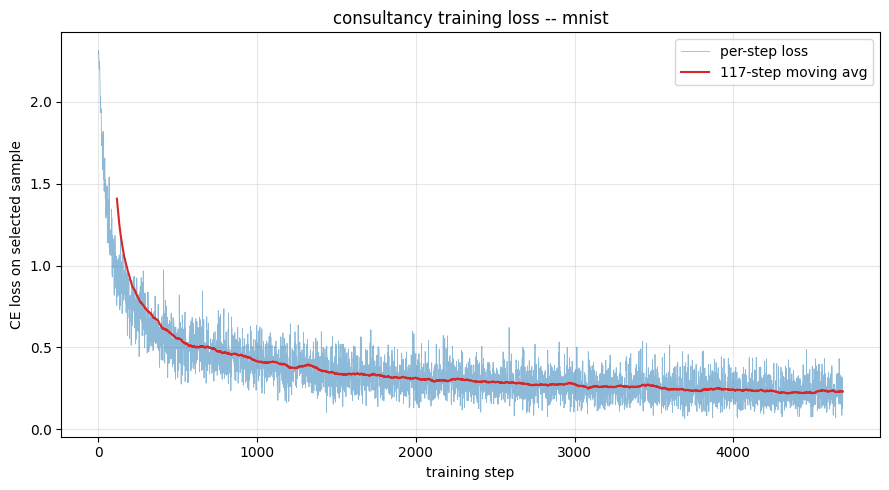

  saved /kaggle/working/combined_judges_plots/consultancy_loss_mnist.png


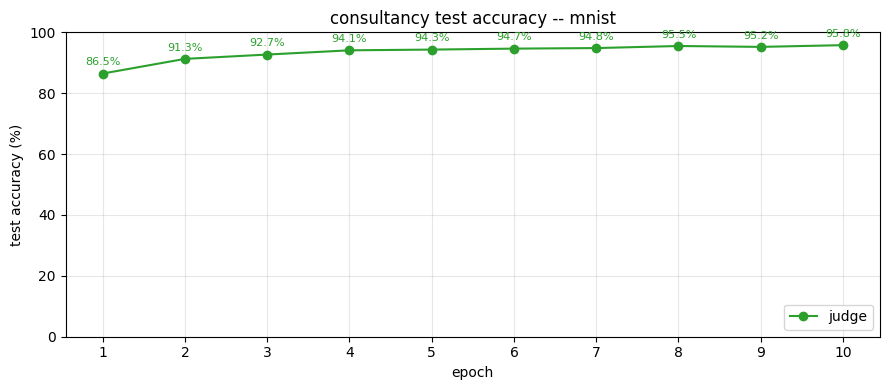

  saved /kaggle/working/combined_judges_plots/consultancy_eval_mnist.png

Final consultancy: judge 95.79%
  weights at /kaggle/working/combined_judges_weights/consultancy_judge_mnist.pt


In [9]:
DATASET_TAG = CONFIG['dataset']
torch.manual_seed(0)
consultancy_judge = make_consultancy_judge(DATA)
print(f"consultancy judge: {sum(p.numel() for p in consultancy_judge.parameters())} params")

cons_weights = os.path.join(CONFIG['weights_dir'], f'consultancy_judge_{DATASET_TAG}.pt')
cons_step_losses, cons_epoch_avg, cons_epoch_metrics = _train_one_judge(
    consultancy_judge, DATA, CONFIG,
    find_best_fn=find_best_consultancy,
    eval_fn=evaluate_consultancy,
    tag='consultancy',
    weights_path=cons_weights)

np.save(os.path.join(CONFIG['data_dir'], f'consultancy_step_loss_{DATASET_TAG}.npy'),
        np.asarray(cons_step_losses, dtype=np.float32))
np.save(os.path.join(CONFIG['data_dir'], f'consultancy_epoch_judge_{DATASET_TAG}.npy'),
        np.asarray([m['judge'] for m in cons_epoch_metrics], dtype=np.float32))
plot_loss_acc(cons_step_losses, cons_epoch_metrics, DATASET_TAG, 'consultancy')

print(f"\nFinal consultancy: judge {cons_epoch_metrics[-1]['judge']*100:.2f}%")
print(f"  weights at {cons_weights}")


## 2) Debate + control judges for each scoring rule

For each rule in `CONFIG['scoring_rules']`, trains four judges (2-turn
debate, 4-turn debate, 2-turn control, 4-turn control). Results are kept
in the dict `ALL_RESULTS[rule]` for the final summary.



##############################################################################
# Scoring rule: asym  (1/3)
##############################################################################

[asym] 2-turn debate judge: 151594 params, in_channels=2


asym_debate_2turn epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [asym_debate_2turn] epoch 01/10 | avg train loss 1.0586 | judge=82.96% | selection=83.57% | elapsed 2.7 min


asym_debate_2turn epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [asym_debate_2turn] epoch 02/10 | avg train loss 0.5977 | judge=87.12% | selection=87.90% | elapsed 5.5 min


...

  [asym_debate_2turn] epoch 08/10 | avg train loss 0.3517 | judge=91.77% | selection=92.01% | elapsed 21.7 min


asym_debate_2turn epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [asym_debate_2turn] epoch 09/10 | avg train loss 0.3410 | judge=92.03% | selection=92.60% | elapsed 24.4 min


asym_debate_2turn epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [asym_debate_2turn] epoch 10/10 | avg train loss 0.3368 | judge=92.30% | selection=92.60% | elapsed 27.1 min


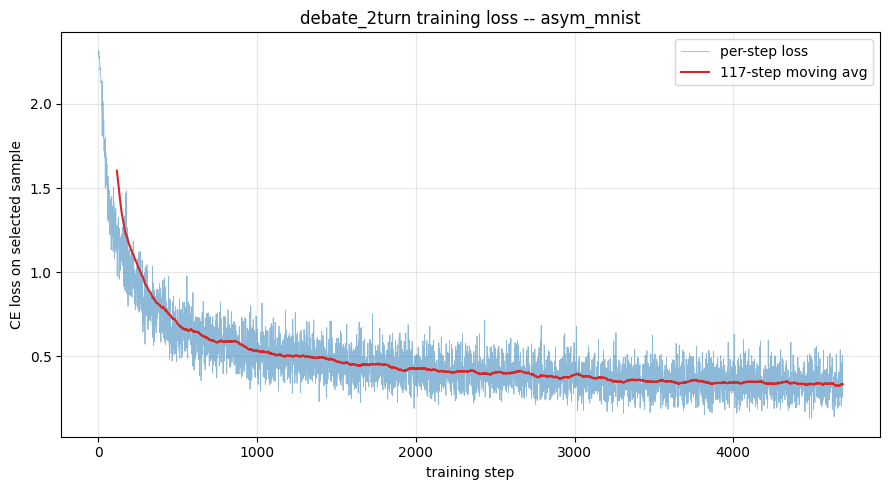

  saved /kaggle/working/combined_judges_plots/debate_2turn_loss_asym_mnist.png


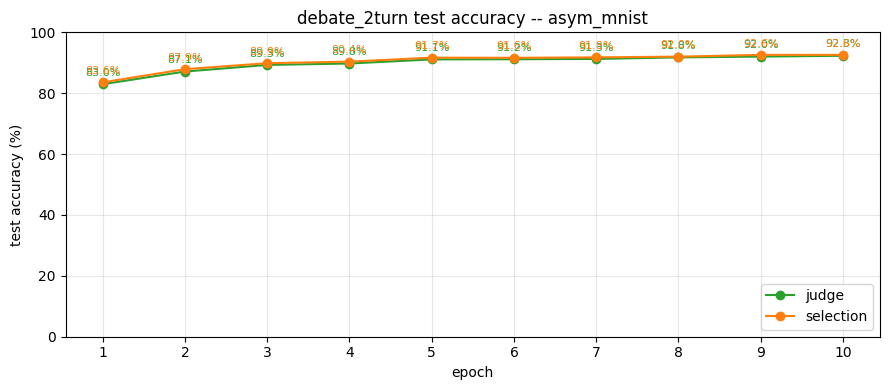

  saved /kaggle/working/combined_judges_plots/debate_2turn_eval_asym_mnist.png
  weights at /kaggle/working/combined_judges_weights/debate_judge_2turn_asym_mnist.pt

[asym] 4-turn debate judge: 151594 params, in_channels=2


asym_debate_4turn epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [asym_debate_4turn] epoch 01/10 | avg train loss 1.4472 | judge=69.02% | selection=73.20% | elapsed 2.7 min


asym_debate_4turn epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [asym_debate_4turn] epoch 02/10 | avg train loss 0.9867 | judge=75.12% | selection=78.33% | elapsed 5.3 min


...

  [asym_debate_4turn] epoch 08/10 | avg train loss 0.6678 | judge=83.49% | selection=85.27% | elapsed 21.3 min


asym_debate_4turn epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [asym_debate_4turn] epoch 09/10 | avg train loss 0.6552 | judge=83.82% | selection=85.67% | elapsed 24.0 min


asym_debate_4turn epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [asym_debate_4turn] epoch 10/10 | avg train loss 0.6406 | judge=85.19% | selection=86.81% | elapsed 26.7 min


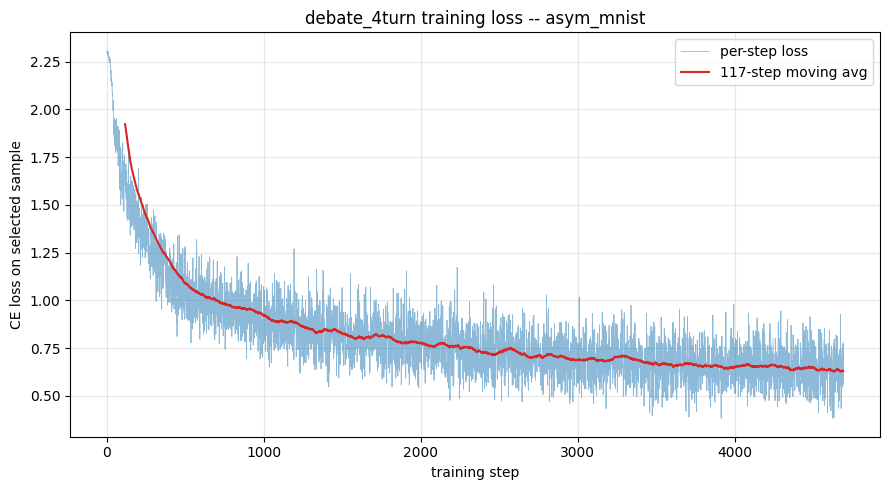

  saved /kaggle/working/combined_judges_plots/debate_4turn_loss_asym_mnist.png


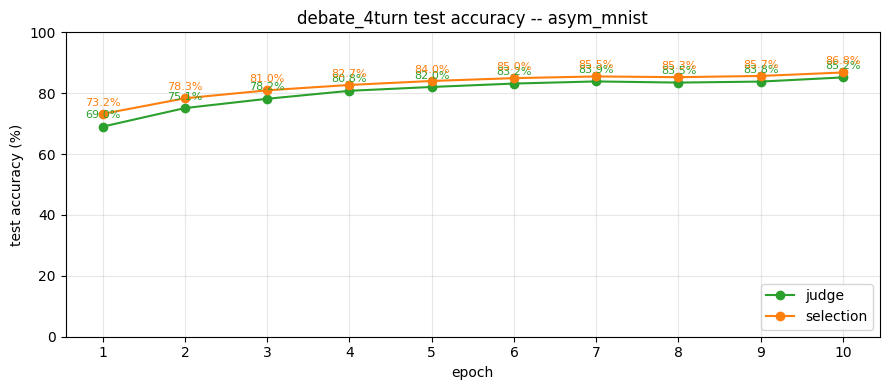

  saved /kaggle/working/combined_judges_plots/debate_4turn_eval_asym_mnist.png
  weights at /kaggle/working/combined_judges_weights/debate_judge_4turn_asym_mnist.pt

[asym] 2-turn control judge: 152170 params, in_channels=4


asym_control_2turn epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [asym_control_2turn] epoch 01/10 | avg train loss 1.2038 | judge=73.44% | selection=81.92% | elapsed 3.0 min


asym_control_2turn epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [asym_control_2turn] epoch 02/10 | avg train loss 0.7304 | judge=78.65% | selection=85.74% | elapsed 6.0 min


...

  [asym_control_2turn] epoch 08/10 | avg train loss 0.4577 | judge=86.21% | selection=91.14% | elapsed 23.8 min


asym_control_2turn epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [asym_control_2turn] epoch 09/10 | avg train loss 0.4478 | judge=86.72% | selection=91.07% | elapsed 26.7 min


asym_control_2turn epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [asym_control_2turn] epoch 10/10 | avg train loss 0.4360 | judge=86.98% | selection=91.43% | elapsed 29.7 min


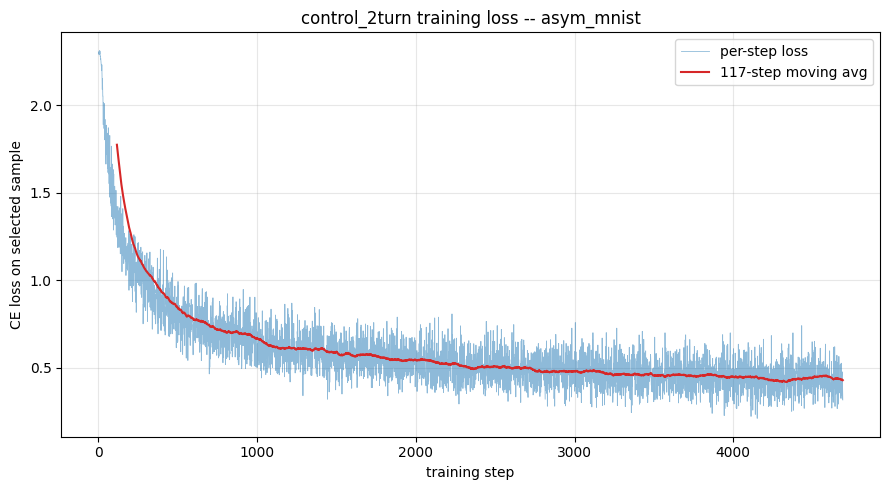

  saved /kaggle/working/combined_judges_plots/control_2turn_loss_asym_mnist.png


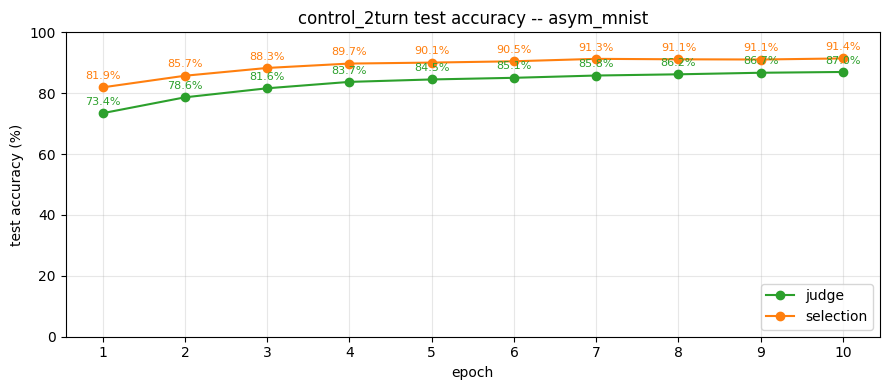

  saved /kaggle/working/combined_judges_plots/control_2turn_eval_asym_mnist.png
  weights at /kaggle/working/combined_judges_weights/control_judge_2turn_asym_mnist.pt

[asym] 4-turn control judge: 152170 params, in_channels=4


asym_control_4turn epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [asym_control_4turn] epoch 01/10 | avg train loss 1.5665 | judge=56.10% | selection=72.52% | elapsed 3.0 min


asym_control_4turn epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [asym_control_4turn] epoch 02/10 | avg train loss 1.1705 | judge=63.15% | selection=77.88% | elapsed 5.9 min


...

  [asym_control_4turn] epoch 08/10 | avg train loss 0.8469 | judge=72.60% | selection=86.28% | elapsed 23.7 min


asym_control_4turn epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [asym_control_4turn] epoch 09/10 | avg train loss 0.8308 | judge=72.82% | selection=86.78% | elapsed 26.7 min


asym_control_4turn epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [asym_control_4turn] epoch 10/10 | avg train loss 0.8237 | judge=73.67% | selection=87.11% | elapsed 29.7 min


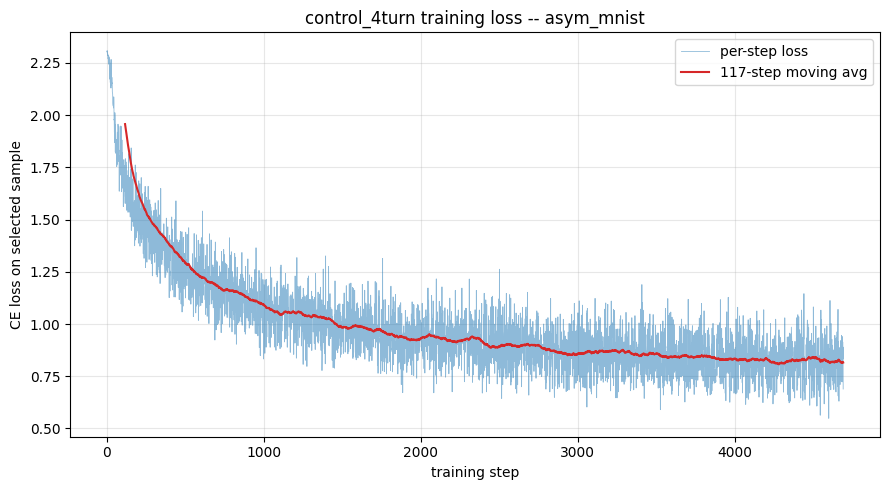

  saved /kaggle/working/combined_judges_plots/control_4turn_loss_asym_mnist.png


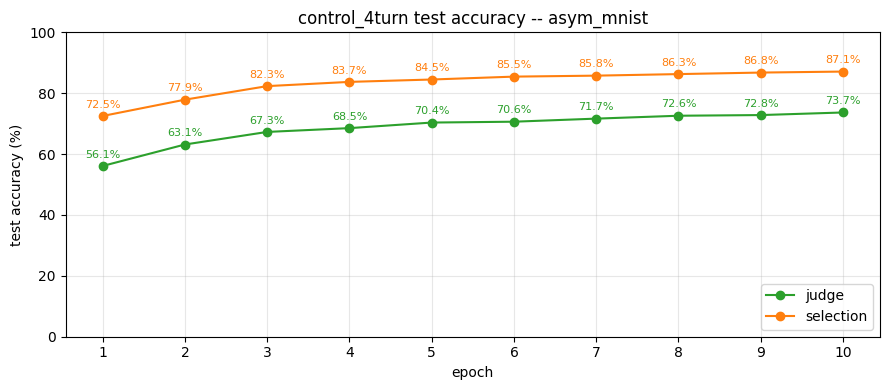

  saved /kaggle/working/combined_judges_plots/control_4turn_eval_asym_mnist.png
  weights at /kaggle/working/combined_judges_weights/control_judge_4turn_asym_mnist.pt

##############################################################################
# Scoring rule: sym  (2/3)
##############################################################################

[sym] 2-turn debate judge: 151594 params, in_channels=2


sym_debate_2turn epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [sym_debate_2turn] epoch 01/10 | avg train loss 1.7358 | judge=47.96% | selection=86.88% | elapsed 2.8 min


sym_debate_2turn epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [sym_debate_2turn] epoch 02/10 | avg train loss 1.4412 | judge=52.63% | selection=91.12% | elapsed 5.6 min


...

  [sym_debate_2turn] epoch 08/10 | avg train loss 1.2351 | judge=58.70% | selection=93.91% | elapsed 22.3 min


sym_debate_2turn epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [sym_debate_2turn] epoch 09/10 | avg train loss 1.2237 | judge=58.26% | selection=94.00% | elapsed 25.1 min


sym_debate_2turn epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [sym_debate_2turn] epoch 10/10 | avg train loss 1.2176 | judge=58.41% | selection=93.80% | elapsed 27.9 min


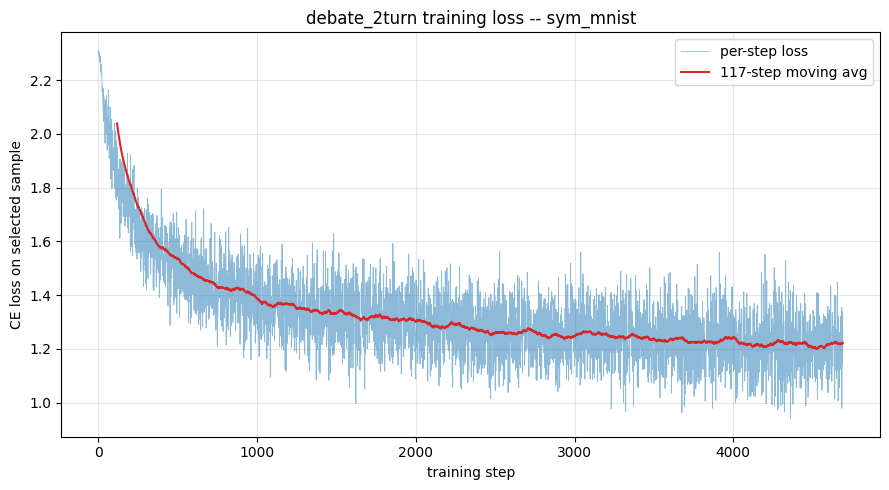

  saved /kaggle/working/combined_judges_plots/debate_2turn_loss_sym_mnist.png


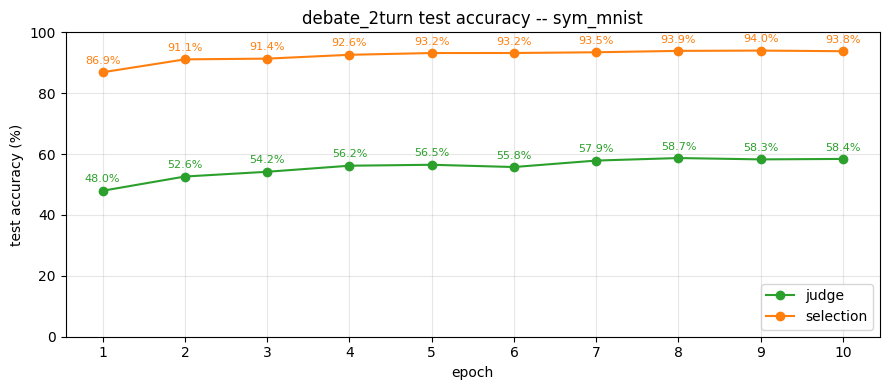

  saved /kaggle/working/combined_judges_plots/debate_2turn_eval_sym_mnist.png
  weights at /kaggle/working/combined_judges_weights/debate_judge_2turn_sym_mnist.pt

[sym] 4-turn debate judge: 151594 params, in_channels=2


sym_debate_4turn epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [sym_debate_4turn] epoch 01/10 | avg train loss 1.8006 | judge=48.51% | selection=78.93% | elapsed 2.7 min


sym_debate_4turn epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [sym_debate_4turn] epoch 02/10 | avg train loss 1.4815 | judge=51.49% | selection=82.36% | elapsed 5.5 min


...

  [sym_debate_4turn] epoch 08/10 | avg train loss 1.2662 | judge=58.09% | selection=87.82% | elapsed 21.7 min


sym_debate_4turn epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [sym_debate_4turn] epoch 09/10 | avg train loss 1.2467 | judge=58.82% | selection=88.52% | elapsed 24.4 min


sym_debate_4turn epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [sym_debate_4turn] epoch 10/10 | avg train loss 1.2387 | judge=58.55% | selection=88.62% | elapsed 27.1 min


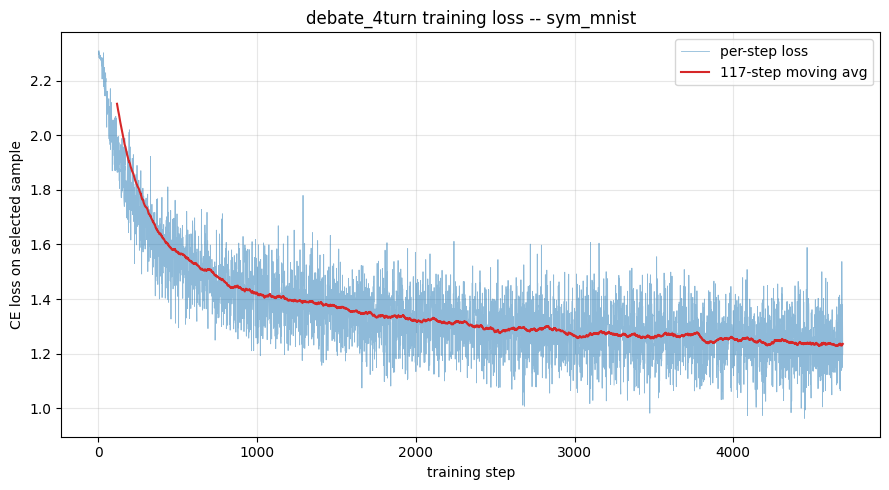

  saved /kaggle/working/combined_judges_plots/debate_4turn_loss_sym_mnist.png


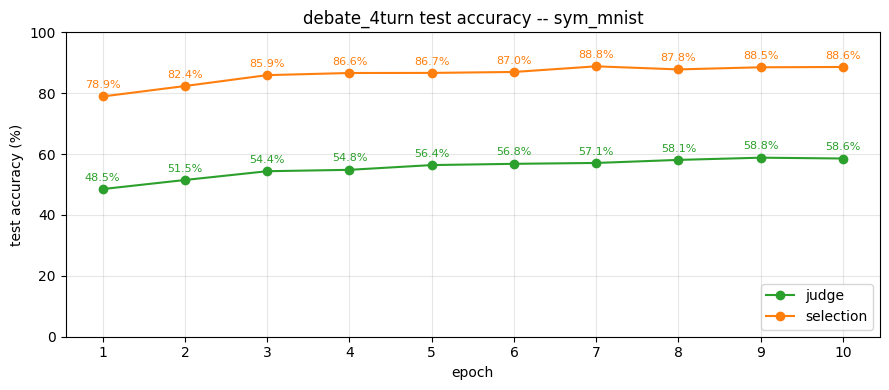

  saved /kaggle/working/combined_judges_plots/debate_4turn_eval_sym_mnist.png
  weights at /kaggle/working/combined_judges_weights/debate_judge_4turn_sym_mnist.pt

[sym] 2-turn control judge: 152170 params, in_channels=4


sym_control_2turn epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [sym_control_2turn] epoch 01/10 | avg train loss 1.7881 | judge=46.75% | selection=87.62% | elapsed 3.0 min


sym_control_2turn epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [sym_control_2turn] epoch 02/10 | avg train loss 1.4846 | judge=51.16% | selection=90.26% | elapsed 6.0 min


...

  [sym_control_2turn] epoch 08/10 | avg train loss 1.2595 | judge=57.75% | selection=93.99% | elapsed 24.0 min


sym_control_2turn epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [sym_control_2turn] epoch 09/10 | avg train loss 1.2441 | judge=58.48% | selection=93.65% | elapsed 27.0 min


sym_control_2turn epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [sym_control_2turn] epoch 10/10 | avg train loss 1.2467 | judge=57.85% | selection=94.26% | elapsed 30.0 min


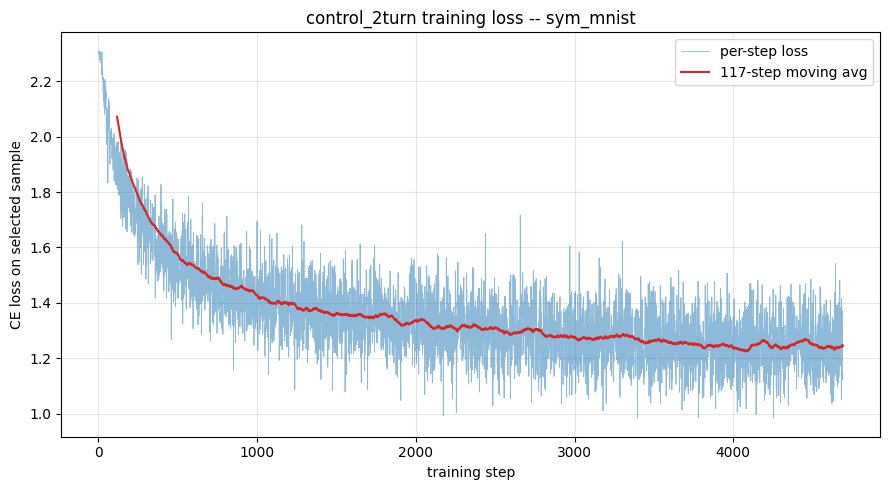

  saved /kaggle/working/combined_judges_plots/control_2turn_loss_sym_mnist.png


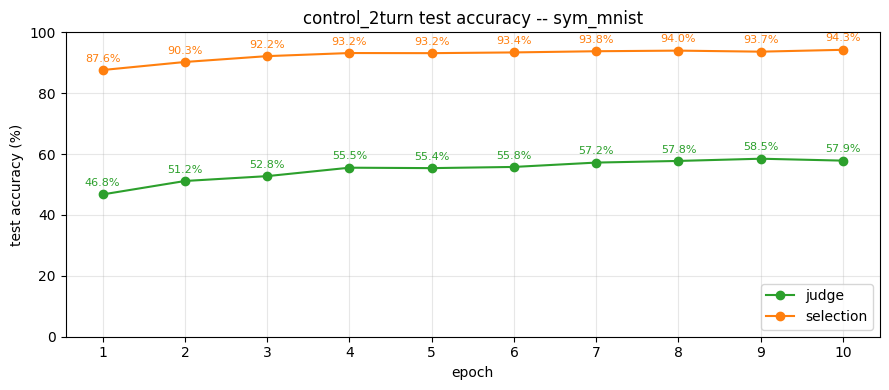

  saved /kaggle/working/combined_judges_plots/control_2turn_eval_sym_mnist.png
  weights at /kaggle/working/combined_judges_weights/control_judge_2turn_sym_mnist.pt

[sym] 4-turn control judge: 152170 params, in_channels=4


sym_control_4turn epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [sym_control_4turn] epoch 01/10 | avg train loss 1.8461 | judge=44.98% | selection=72.30% | elapsed 3.0 min


sym_control_4turn epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [sym_control_4turn] epoch 02/10 | avg train loss 1.5223 | judge=50.19% | selection=81.00% | elapsed 6.0 min


...

  [sym_control_4turn] epoch 08/10 | avg train loss 1.3019 | judge=56.94% | selection=87.38% | elapsed 23.9 min


sym_control_4turn epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [sym_control_4turn] epoch 09/10 | avg train loss 1.2878 | judge=56.82% | selection=87.69% | elapsed 26.9 min


sym_control_4turn epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [sym_control_4turn] epoch 10/10 | avg train loss 1.2830 | judge=57.77% | selection=88.19% | elapsed 29.9 min


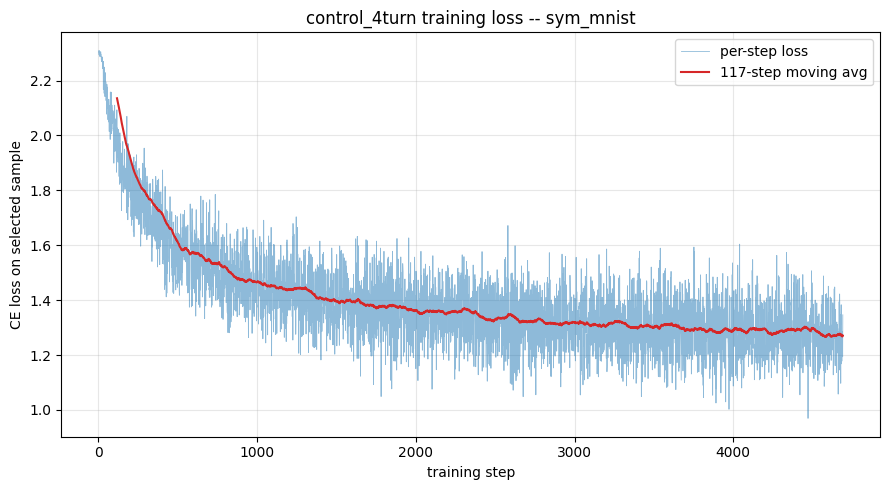

  saved /kaggle/working/combined_judges_plots/control_4turn_loss_sym_mnist.png


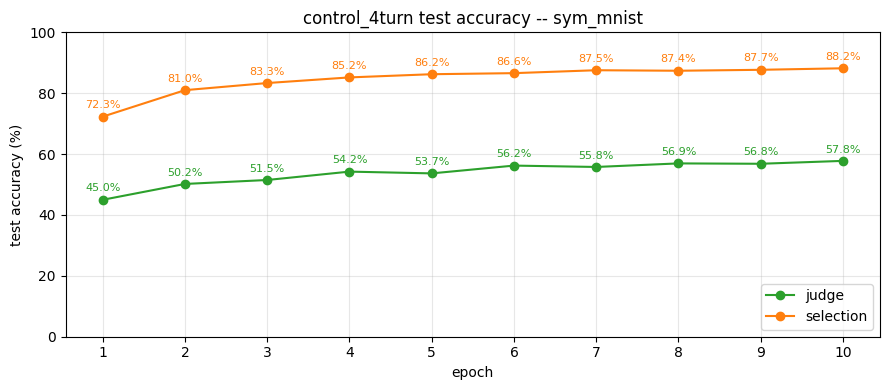

  saved /kaggle/working/combined_judges_plots/control_4turn_eval_sym_mnist.png
  weights at /kaggle/working/combined_judges_weights/control_judge_4turn_sym_mnist.pt

##############################################################################
# Scoring rule: lastdig  (3/3)
##############################################################################

[lastdig] 2-turn debate judge: 151594 params, in_channels=2


lastdig_debate_2turn epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [lastdig_debate_2turn] epoch 01/10 | avg train loss 1.2324 | judge=78.34% | selection=79.04% | elapsed 2.8 min


lastdig_debate_2turn epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [lastdig_debate_2turn] epoch 02/10 | avg train loss 0.7691 | judge=82.76% | selection=83.26% | elapsed 5.5 min


...

  [lastdig_debate_2turn] epoch 08/10 | avg train loss 0.5387 | judge=86.29% | selection=86.67% | elapsed 22.1 min


lastdig_debate_2turn epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [lastdig_debate_2turn] epoch 09/10 | avg train loss 0.5240 | judge=87.66% | selection=88.18% | elapsed 24.9 min


lastdig_debate_2turn epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [lastdig_debate_2turn] epoch 10/10 | avg train loss 0.5161 | judge=87.83% | selection=88.08% | elapsed 27.6 min


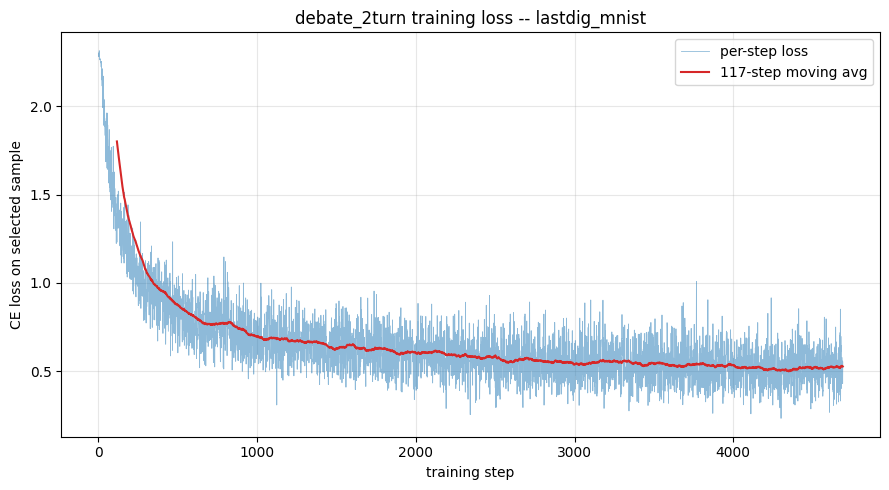

  saved /kaggle/working/combined_judges_plots/debate_2turn_loss_lastdig_mnist.png


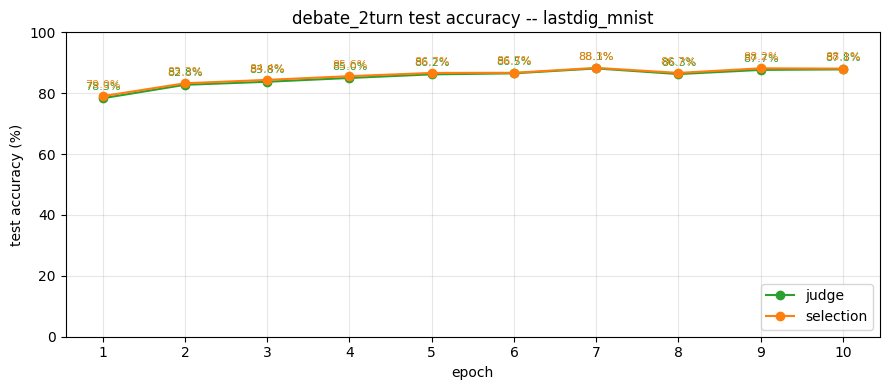

  saved /kaggle/working/combined_judges_plots/debate_2turn_eval_lastdig_mnist.png
  weights at /kaggle/working/combined_judges_weights/debate_judge_2turn_lastdig_mnist.pt

[lastdig] 4-turn debate judge: 151594 params, in_channels=2


lastdig_debate_4turn epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [lastdig_debate_4turn] epoch 01/10 | avg train loss 1.5012 | judge=66.92% | selection=72.83% | elapsed 2.7 min


lastdig_debate_4turn epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [lastdig_debate_4turn] epoch 02/10 | avg train loss 1.0525 | judge=73.48% | selection=78.36% | elapsed 5.4 min


...

  [lastdig_debate_4turn] epoch 08/10 | avg train loss 0.7700 | judge=80.67% | selection=84.42% | elapsed 21.7 min


lastdig_debate_4turn epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [lastdig_debate_4turn] epoch 09/10 | avg train loss 0.7458 | judge=80.64% | selection=83.95% | elapsed 24.4 min


lastdig_debate_4turn epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [lastdig_debate_4turn] epoch 10/10 | avg train loss 0.7390 | judge=81.35% | selection=84.61% | elapsed 27.1 min


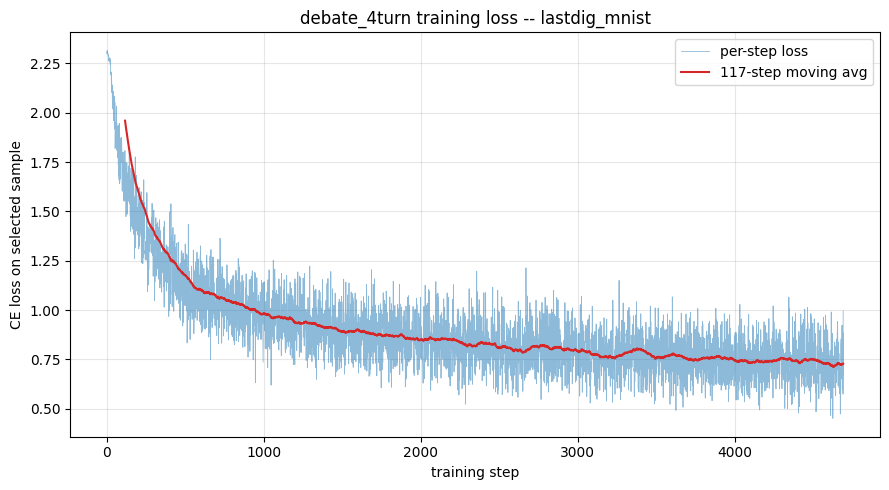

  saved /kaggle/working/combined_judges_plots/debate_4turn_loss_lastdig_mnist.png


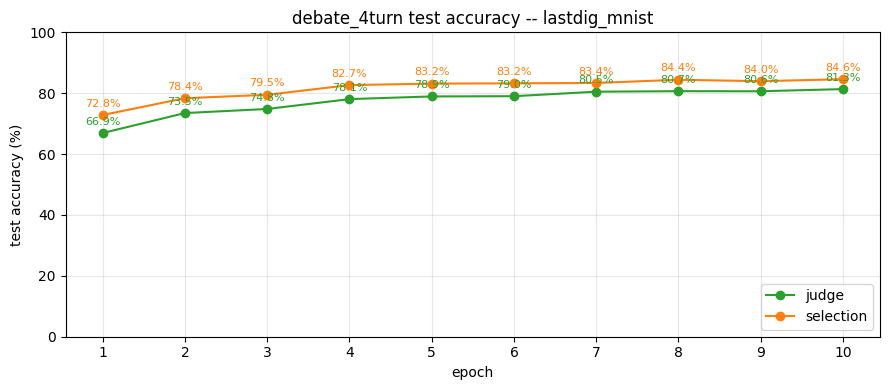

  saved /kaggle/working/combined_judges_plots/debate_4turn_eval_lastdig_mnist.png
  weights at /kaggle/working/combined_judges_weights/debate_judge_4turn_lastdig_mnist.pt

[lastdig] 2-turn control judge: 152170 params, in_channels=4


lastdig_control_2turn epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [lastdig_control_2turn] epoch 01/10 | avg train loss 1.2830 | judge=72.33% | selection=81.54% | elapsed 3.0 min


lastdig_control_2turn epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [lastdig_control_2turn] epoch 02/10 | avg train loss 0.7567 | judge=78.91% | selection=85.86% | elapsed 5.9 min


...

  [lastdig_control_2turn] epoch 08/10 | avg train loss 0.4736 | judge=86.34% | selection=91.29% | elapsed 23.8 min


lastdig_control_2turn epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [lastdig_control_2turn] epoch 09/10 | avg train loss 0.4621 | judge=86.25% | selection=91.81% | elapsed 26.7 min


lastdig_control_2turn epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [lastdig_control_2turn] epoch 10/10 | avg train loss 0.4467 | judge=86.80% | selection=92.11% | elapsed 29.7 min


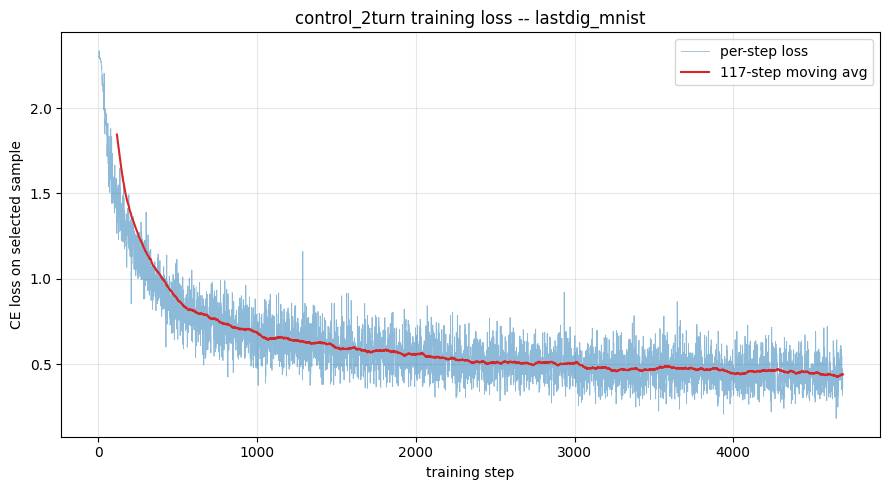

  saved /kaggle/working/combined_judges_plots/control_2turn_loss_lastdig_mnist.png


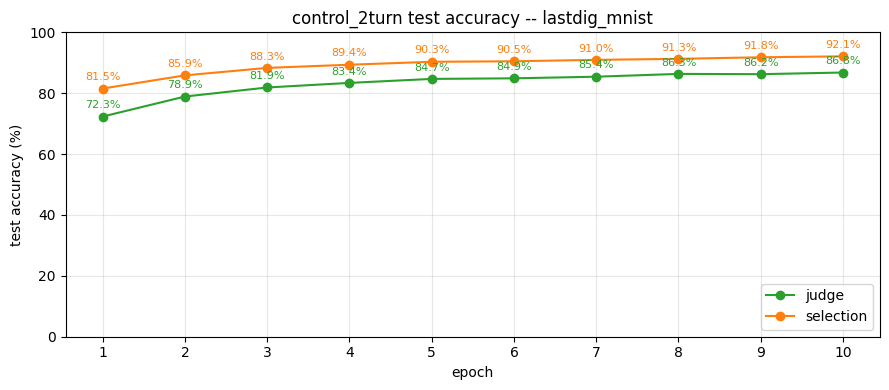

  saved /kaggle/working/combined_judges_plots/control_2turn_eval_lastdig_mnist.png
  weights at /kaggle/working/combined_judges_weights/control_judge_2turn_lastdig_mnist.pt

[lastdig] 4-turn control judge: 152170 params, in_channels=4


lastdig_control_4turn epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [lastdig_control_4turn] epoch 01/10 | avg train loss 1.6477 | judge=53.24% | selection=68.52% | elapsed 3.0 min


lastdig_control_4turn epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [lastdig_control_4turn] epoch 02/10 | avg train loss 1.2344 | judge=61.45% | selection=78.20% | elapsed 5.9 min


...

  [lastdig_control_4turn] epoch 08/10 | avg train loss 0.9368 | judge=71.83% | selection=86.13% | elapsed 23.8 min


lastdig_control_4turn epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [lastdig_control_4turn] epoch 09/10 | avg train loss 0.9206 | judge=71.57% | selection=86.66% | elapsed 26.7 min


lastdig_control_4turn epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

  [lastdig_control_4turn] epoch 10/10 | avg train loss 0.9090 | judge=72.48% | selection=86.43% | elapsed 29.7 min


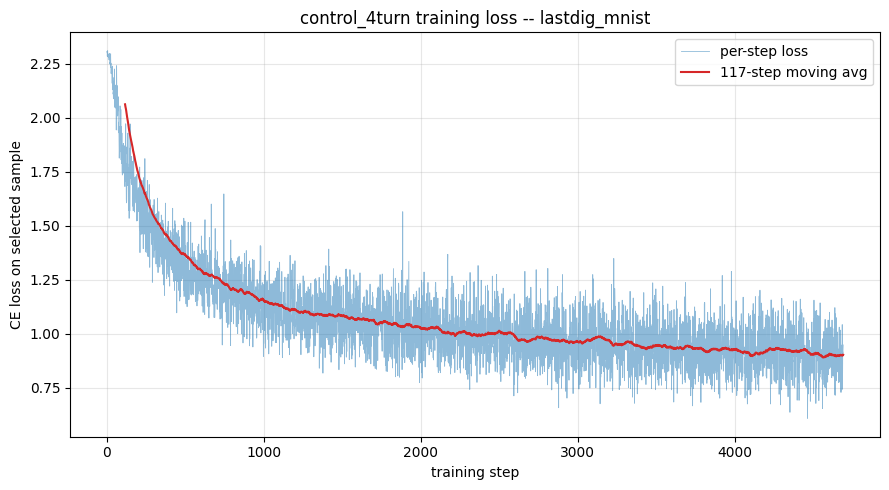

  saved /kaggle/working/combined_judges_plots/control_4turn_loss_lastdig_mnist.png


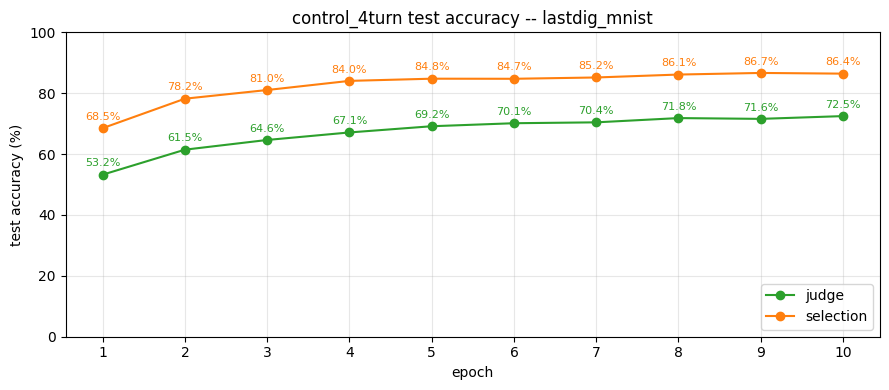

  saved /kaggle/working/combined_judges_plots/control_4turn_eval_lastdig_mnist.png
  weights at /kaggle/working/combined_judges_weights/control_judge_4turn_lastdig_mnist.pt


In [10]:
from functools import partial

ALL_RESULTS = {}                                                # rule -> dict(judge_kind -> metrics)
ALL_RESULTS['consultancy'] = {'final': cons_epoch_metrics[-1]}

for rule_idx, rule in enumerate(CONFIG['scoring_rules']):
    reduce_2 = SCORING_RULES[rule]['reduce_2turn']
    reduce_4 = SCORING_RULES[rule]['reduce_4turn']

    fb_2turn         = partial(find_best_2turn,         reduce_fn=reduce_2)
    fb_4turn         = partial(find_best_4turn,         reduce_fn=reduce_4)
    fb_2turn_control = partial(find_best_2turn_control, reduce_fn=reduce_2)
    fb_4turn_control = partial(find_best_4turn_control, reduce_fn=reduce_4)

    eval_2turn         = lambda j, d, c, fb=fb_2turn:         _evaluate_with_claim(j, d, c, fb)
    eval_4turn         = lambda j, d, c, fb=fb_4turn:         _evaluate_with_claim(j, d, c, fb)
    eval_2turn_control = lambda j, d, c, fb=fb_2turn_control: _evaluate_with_claim(j, d, c, fb)
    eval_4turn_control = lambda j, d, c, fb=fb_4turn_control: _evaluate_with_claim(j, d, c, fb)

    rule_tag = f'{rule}_{DATASET_TAG}'
    ALL_RESULTS[rule] = {}

    print("\n" + "#" * 78)
    print(f"# Scoring rule: {rule}  ({rule_idx+1}/{len(CONFIG['scoring_rules'])})")
    print("#" * 78)

    # ---- 2-turn debate ----
    torch.manual_seed(1 + 10 * rule_idx)
    debate2_judge = make_debate_judge(DATA)
    print(f"\n[{rule}] 2-turn debate judge: "
          f"{sum(p.numel() for p in debate2_judge.parameters())} params, "
          f"in_channels={2 * DATA['in_channels']}")
    d2_weights = os.path.join(CONFIG['weights_dir'], f'debate_judge_2turn_{rule_tag}.pt')
    d2_step, _, d2_metrics = _train_one_judge(
        debate2_judge, DATA, CONFIG,
        find_best_fn=fb_2turn, eval_fn=eval_2turn,
        tag=f'{rule}_debate_2turn', weights_path=d2_weights)
    np.save(os.path.join(CONFIG['data_dir'], f'debate2_step_loss_{rule_tag}.npy'),
            np.asarray(d2_step, dtype=np.float32))
    np.save(os.path.join(CONFIG['data_dir'], f'debate2_epoch_judge_{rule_tag}.npy'),
            np.asarray([m['judge']     for m in d2_metrics], dtype=np.float32))
    np.save(os.path.join(CONFIG['data_dir'], f'debate2_epoch_selection_{rule_tag}.npy'),
            np.asarray([m['selection'] for m in d2_metrics], dtype=np.float32))
    plot_loss_acc(d2_step, d2_metrics, rule_tag, 'debate_2turn')
    ALL_RESULTS[rule]['debate_2turn'] = d2_metrics[-1]
    print(f"  weights at {d2_weights}")
    del debate2_judge; gc.collect()
    if CONFIG['device'] == 'cuda': torch.cuda.empty_cache()

    # ---- 4-turn debate ----
    torch.manual_seed(2 + 10 * rule_idx)
    debate4_judge = make_debate_judge(DATA)
    print(f"\n[{rule}] 4-turn debate judge: "
          f"{sum(p.numel() for p in debate4_judge.parameters())} params, "
          f"in_channels={2 * DATA['in_channels']}")
    d4_weights = os.path.join(CONFIG['weights_dir'], f'debate_judge_4turn_{rule_tag}.pt')
    d4_step, _, d4_metrics = _train_one_judge(
        debate4_judge, DATA, CONFIG,
        find_best_fn=fb_4turn, eval_fn=eval_4turn,
        tag=f'{rule}_debate_4turn', weights_path=d4_weights)
    np.save(os.path.join(CONFIG['data_dir'], f'debate4_step_loss_{rule_tag}.npy'),
            np.asarray(d4_step, dtype=np.float32))
    np.save(os.path.join(CONFIG['data_dir'], f'debate4_epoch_judge_{rule_tag}.npy'),
            np.asarray([m['judge']     for m in d4_metrics], dtype=np.float32))
    np.save(os.path.join(CONFIG['data_dir'], f'debate4_epoch_selection_{rule_tag}.npy'),
            np.asarray([m['selection'] for m in d4_metrics], dtype=np.float32))
    plot_loss_acc(d4_step, d4_metrics, rule_tag, 'debate_4turn')
    ALL_RESULTS[rule]['debate_4turn'] = d4_metrics[-1]
    print(f"  weights at {d4_weights}")
    del debate4_judge; gc.collect()
    if CONFIG['device'] == 'cuda': torch.cuda.empty_cache()

    # ---- 2-turn control ----
    torch.manual_seed(3 + 10 * rule_idx)
    control2_judge = make_control_judge(DATA)
    print(f"\n[{rule}] 2-turn control judge: "
          f"{sum(p.numel() for p in control2_judge.parameters())} params, "
          f"in_channels={4 * DATA['in_channels']}")
    c2_weights = os.path.join(CONFIG['weights_dir'], f'control_judge_2turn_{rule_tag}.pt')
    c2_step, _, c2_metrics = _train_one_judge(
        control2_judge, DATA, CONFIG,
        find_best_fn=fb_2turn_control, eval_fn=eval_2turn_control,
        tag=f'{rule}_control_2turn', weights_path=c2_weights)
    np.save(os.path.join(CONFIG['data_dir'], f'control2_step_loss_{rule_tag}.npy'),
            np.asarray(c2_step, dtype=np.float32))
    np.save(os.path.join(CONFIG['data_dir'], f'control2_epoch_judge_{rule_tag}.npy'),
            np.asarray([m['judge']     for m in c2_metrics], dtype=np.float32))
    np.save(os.path.join(CONFIG['data_dir'], f'control2_epoch_selection_{rule_tag}.npy'),
            np.asarray([m['selection'] for m in c2_metrics], dtype=np.float32))
    plot_loss_acc(c2_step, c2_metrics, rule_tag, 'control_2turn')
    ALL_RESULTS[rule]['control_2turn'] = c2_metrics[-1]
    print(f"  weights at {c2_weights}")
    del control2_judge; gc.collect()
    if CONFIG['device'] == 'cuda': torch.cuda.empty_cache()

    # ---- 4-turn control ----
    torch.manual_seed(4 + 10 * rule_idx)
    control4_judge = make_control_judge(DATA)
    print(f"\n[{rule}] 4-turn control judge: "
          f"{sum(p.numel() for p in control4_judge.parameters())} params, "
          f"in_channels={4 * DATA['in_channels']}")
    c4_weights = os.path.join(CONFIG['weights_dir'], f'control_judge_4turn_{rule_tag}.pt')
    c4_step, _, c4_metrics = _train_one_judge(
        control4_judge, DATA, CONFIG,
        find_best_fn=fb_4turn_control, eval_fn=eval_4turn_control,
        tag=f'{rule}_control_4turn', weights_path=c4_weights)
    np.save(os.path.join(CONFIG['data_dir'], f'control4_step_loss_{rule_tag}.npy'),
            np.asarray(c4_step, dtype=np.float32))
    np.save(os.path.join(CONFIG['data_dir'], f'control4_epoch_judge_{rule_tag}.npy'),
            np.asarray([m['judge']     for m in c4_metrics], dtype=np.float32))
    np.save(os.path.join(CONFIG['data_dir'], f'control4_epoch_selection_{rule_tag}.npy'),
            np.asarray([m['selection'] for m in c4_metrics], dtype=np.float32))
    plot_loss_acc(c4_step, c4_metrics, rule_tag, 'control_4turn')
    ALL_RESULTS[rule]['control_4turn'] = c4_metrics[-1]
    print(f"  weights at {c4_weights}")
    del control4_judge; gc.collect()
    if CONFIG['device'] == 'cuda': torch.cuda.empty_cache()


## 3) Final summary table

In [11]:
print("=" * 88)
print(f"SUMMARY for dataset '{DATASET_TAG}'")
print("=" * 88)
print(f"  {'rule':<10s}  {'judge':<18s}  {'judge acc':>10s}  {'A selection acc':>16s}")
print(f"  {'-'*10}  {'-'*18}  {'-'*10}  {'-'*16}")
print(f"  {'--':<10s}  {'consultancy':<18s}  "
      f"{ALL_RESULTS['consultancy']['final']['judge']*100:>9.2f}%  {'-':>16s}")
for rule in CONFIG['scoring_rules']:
    for kind in ('debate_2turn', 'debate_4turn', 'control_2turn', 'control_4turn'):
        m = ALL_RESULTS[rule][kind]
        print(f"  {rule:<10s}  {kind:<18s}  "
              f"{m['judge']*100:>9.2f}%  {m['selection']*100:>15.2f}%")


SUMMARY for dataset 'mnist'
  rule        judge                judge acc   A selection acc
  ----------  ------------------  ----------  ----------------
  --          consultancy             95.79%                 -
  asym        debate_2turn            92.30%            92.60%
  asym        debate_4turn            85.19%            86.81%
  asym        control_2turn           86.98%            91.43%
  asym        control_4turn           73.67%            87.11%
  sym         debate_2turn            58.41%            93.80%
  sym         debate_4turn            58.55%            88.62%
  sym         control_2turn           57.85%            94.26%
  sym         control_4turn           57.77%            88.19%
  lastdig     debate_2turn            87.83%            88.08%
  lastdig     debate_4turn            81.35%            84.61%
  lastdig     control_2turn           86.80%            92.11%
  lastdig     control_4turn           72.48%            86.43%
